# 2.1 · EDA de features y selección de variables

## 0. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import StratifiedKFold
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
C_AZUL, C_ROJO = '#2E86AB', '#E84855'
PALETA4 = ['#8ecae6', '#219ebc', '#fb8500', '#e63946']

from pathlib import Path

In [2]:
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'
path_df_features = PROJECT_DIR + '/output/df_acoustic_features_vf.csv'
path_output      = PROJECT_DIR + '/output'

PHQ_THRESHOLD = 10
RANDOM_STATE  = 42
N_CV_FOLDS    = 5
K_FEATURES    = 20

COLS_EXCLUDE = ['participant_id', 'phq8_binary', 'path_audio',
                'path_transcript', 'split', 'durAudio', 'durSession']
TARGET = 'phq8_score'

ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

df = pd.read_csv(path_df_features)
COLS_FEATURES = [c for c in df.columns if c not in COLS_EXCLUDE + [TARGET]]
ACOUSTIC_COLS = [c for c in COLS_FEATURES if c.startswith(ACOUSTIC_PREFIXES)]
OTHER_COLS    = [c for c in COLS_FEATURES if c not in ACOUSTIC_COLS]

print(f'Sesiones: {len(df)} | columnas de feature: {len(COLS_FEATURES)}')
print(f'  acusticas          : {len(ACOUSTIC_COLS)}')
print(f'  turnos/pausas+sexo : {len(OTHER_COLS)}')

Sesiones: 186 | columnas de feature: 60
  acusticas          : 45
  turnos/pausas+sexo : 15


## 1. Resultado de la extracción

Composición del conjunto de variables e incidencias.

In [3]:
def bloque(c):
    """Clasifica cada variable en su bloque tematico (el de la Tabla 4 de la memoria)."""
    if c == 'gender':
        return 'Sexo'
    if 'Pause' in c or 'Turns' in c or c.startswith('nTurns'):
        return 'Turnos y pausas'
    if c.startswith(('f0_', 'energy_')):
        return 'Prosodia'
    if c.startswith(('hnr_', 'jitter_', 'shimmer_')):
        return 'Calidad vocal'
    return 'Articulación'


BLOQUE = {c: bloque(c) for c in COLS_FEATURES}
resumen = (pd.Series(BLOQUE).value_counts()
             .rename_axis('Bloque').rename('N.o de variables').to_frame())
print(resumen.to_string())
print(f'\nTOTAL: {len(COLS_FEATURES)}')

# incidencias de la extraccion
nan = df[COLS_FEATURES].isna().sum()
nan = nan[nan > 0]
print(f'\nValores ausentes: {"ninguno" if len(nan) == 0 else ""}')
if len(nan):
    print(nan.to_string())
print(f'Sesiones con alguna variable ausente: {df[COLS_FEATURES].isna().any(axis=1).sum()}')

                 N.o de variables
Bloque                           
Articulación                   34
Turnos y pausas                14
Calidad vocal                   6
Prosodia                        5
Sexo                            1

TOTAL: 60

Valores ausentes: ninguno
Sesiones con alguna variable ausente: 0


## 2. Efecto de la normalización por sexo

Se cuantifica el dimorfismo con la *d* de Cohen antes y después de la normalización intra-sexo.

In [4]:
# Dimorfismo sexual: d de Cohen de cada acustica entre hombres y mujeres
def cohen_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s if s > 0 else 0.0

g0, g1 = df[df.gender == 0], df[df.gender == 1]
d_antes = pd.Series({c: abs(cohen_d(g0[c], g1[c])) for c in ACOUSTIC_COLS})

# normalizacion intra-sexo (misma operacion que GenderZScoreScaler)
df_norm = df.copy()
for g, idx in df.groupby('gender').groups.items():
    mu = df.loc[idx, ACOUSTIC_COLS].mean()
    sd = df.loc[idx, ACOUSTIC_COLS].std(ddof=0).replace(0, 1.0)
    df_norm.loc[idx, ACOUSTIC_COLS] = (df.loc[idx, ACOUSTIC_COLS] - mu) / sd

h0, h1 = df_norm[df_norm.gender == 0], df_norm[df_norm.gender == 1]
d_despues = pd.Series({c: abs(cohen_d(h0[c], h1[c])) for c in ACOUSTIC_COLS})

tab_dim = (pd.DataFrame({'|d| antes': d_antes, '|d| despues': d_despues})
             .sort_values('|d| antes', ascending=False))
print('Variables acusticas con mayor dimorfismo sexual (d de Cohen en valor absoluto):')
print(tab_dim.head(10).round(3).to_string())
print(f'\n|d| medio antes de normalizar : {d_antes.mean():.3f}')
print(f'|d| medio despues            : {d_despues.mean():.3f}')
print(f'Variables con |d| > 0.5 antes : {(d_antes > 0.5).sum()} de {len(ACOUSTIC_COLS)}')
print(f'Variables con |d| > 0.5 despues: {(d_despues > 0.5).sum()} de {len(ACOUSTIC_COLS)}')

Variables acusticas con mayor dimorfismo sexual (d de Cohen en valor absoluto):
             |d| antes  |d| despues
f0_mean          4.022          0.0
mfcc12_mean      1.238          0.0
f0_std           1.207          0.0
mfcc11_mean      1.182          0.0
mfcc02_std       1.156          0.0
mfcc10_mean      1.120          0.0
mfcc05_mean      1.058          0.0
mfcc04_mean      1.054          0.0
hnr_mean         0.969          0.0
mfcc02_mean      0.967          0.0

|d| medio antes de normalizar : 0.604
|d| medio despues            : 0.000
Variables con |d| > 0.5 antes : 25 de 45
Variables con |d| > 0.5 despues: 0 de 45


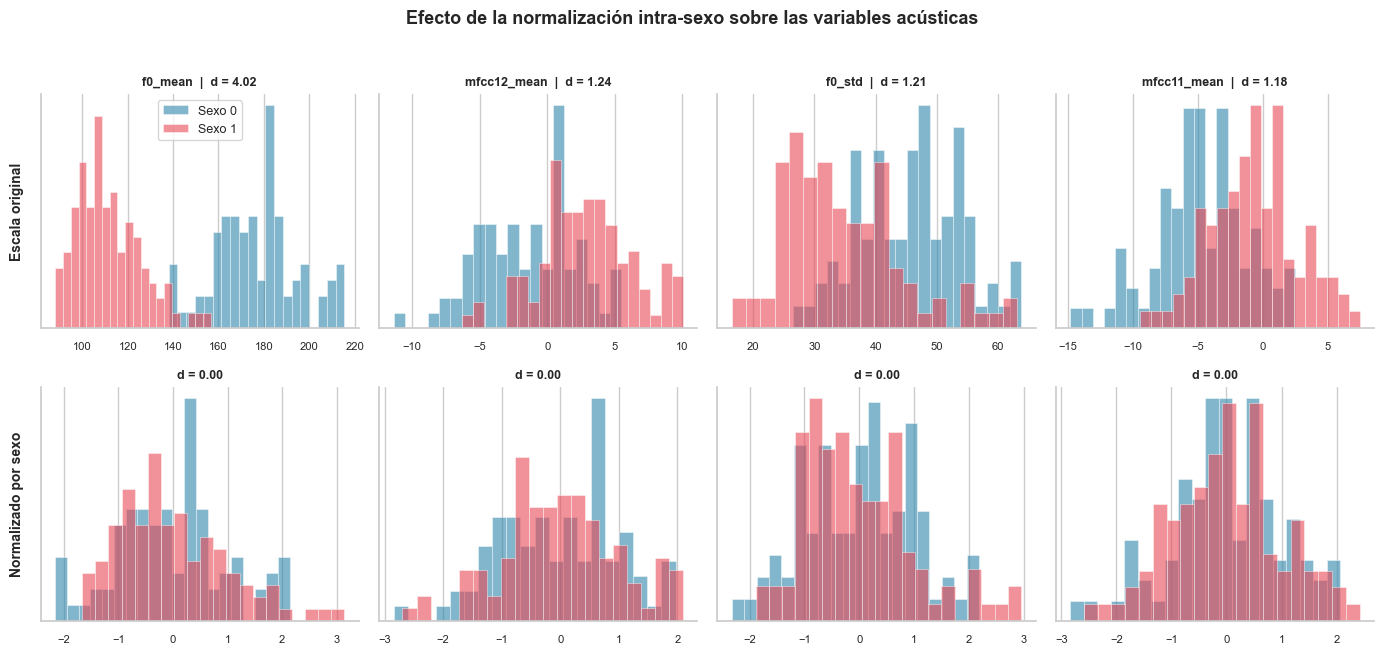

In [5]:
# Figura: efecto de la normalizacion sobre las 4 variables mas dimorficas
top4 = tab_dim.head(4).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(14, 6.4))
COL = {0: C_AZUL, 1: C_ROJO}
ETQ = {0: 'Sexo 0', 1: 'Sexo 1'}

for j, c in enumerate(top4):
    for g in (0, 1):
        axes[0, j].hist(df.loc[df.gender == g, c], bins=20, alpha=0.6, color=COL[g],
                        edgecolor='white', linewidth=0.5, label=ETQ[g], density=True)
        axes[1, j].hist(df_norm.loc[df_norm.gender == g, c], bins=20, alpha=0.6, color=COL[g],
                        edgecolor='white', linewidth=0.5, label=ETQ[g], density=True)
    axes[0, j].set_title(f'{c}  |  d = {tab_dim.loc[c, "|d| antes"]:.2f}',
                         fontsize=9, fontweight='bold')
    axes[1, j].set_title(f'd = {tab_dim.loc[c, "|d| despues"]:.2f}',
                         fontsize=9, fontweight='bold')
    for r in (0, 1):
        axes[r, j].set_yticks([])
        axes[r, j].tick_params(axis='x', labelsize=8)
        axes[r, j].spines[['top', 'right']].set_visible(False)

axes[0, 0].set_ylabel('Escala original', fontsize=10, fontweight='bold', labelpad=12)
axes[1, 0].set_ylabel('Normalizado por sexo', fontsize=10, fontweight='bold', labelpad=12)
axes[0, 0].legend(fontsize=9)

plt.suptitle('Efecto de la normalización intra-sexo sobre las variables acústicas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(path_output + '/eda_normalizacion_sexo.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

## 3. Selección de variables

`SelectKBest` con F de regresión, k = 20, sobre el mismo preprocesado y las mismas particiones que la línea principal.

In [6]:
# Seleccion de variables: mismo preprocesado y mismas particiones que la linea principal
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    def __init__(self, cols, gender_col='gender'):
        self.cols, self.gender_col = cols, gender_col
    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            self.stats_[g] = (sub[self.cols].mean(),
                              sub[self.cols].std(ddof=0).replace(0, 1.0))
        self.global_ = (X[self.cols].mean(), X[self.cols].std(ddof=0).replace(0, 1.0))
        return self
    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X


class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X.drop(columns=[c for c in self.cols if c in X.columns])


def build_prep():
    return Pipeline([('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
                     ('dropgender', DropColumns(['gender'])),
                     ('scaler',     StandardScaler()),
                     ('select',     SelectKBest(f_regression, k=K_FEATURES))])


td = df[df.split.isin(['train', 'dev'])]
X_td, y_td = td[COLS_FEATURES], td[TARGET]
ybin_td = (y_td >= PHQ_THRESHOLD).astype(int)

# 1) seleccion definitiva: ajustada sobre todo train+dev (la del modelo final)
prep = build_prep().fit(X_td, y_td)
sel  = prep.named_steps['select']
cols_sin_sexo = [c for c in COLS_FEATURES if c != 'gender']
mask = sel.get_support()

# 2) estabilidad: cuantos de los 5 folds seleccionan cada variable
cv = StratifiedKFold(N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
veces = pd.Series(0, index=cols_sin_sexo)
for i_tr, _ in cv.split(X_td, ybin_td):
    p = build_prep().fit(X_td.iloc[i_tr], y_td.iloc[i_tr])
    veces[np.array(cols_sin_sexo)[p.named_steps['select'].get_support()]] += 1

tab_sel = (pd.DataFrame({'Variable': cols_sin_sexo,
                         'Bloque': [BLOQUE[c] for c in cols_sin_sexo],
                         'F': sel.scores_, 'p': sel.pvalues_,
                         'Folds': veces.values, 'Sel': mask})
             .sort_values('F', ascending=False).reset_index(drop=True))
tab_sel.insert(0, '#', tab_sel.index + 1)

print(f'Variables candidatas: {len(cols_sin_sexo)}  ->  seleccionadas: {mask.sum()}\n')
print(tab_sel[tab_sel.Sel].drop(columns='Sel').round(3).to_string(index=False))

Variables candidatas: 59  ->  seleccionadas: 20

 #             Variable          Bloque      F     p  Folds
 1   sumPause_inter_pat Turnos y pausas 12.479 0.001      5
 2       f0_voiced_frac        Prosodia  9.320 0.003      5
 3   avgPause_inter_pat Turnos y pausas  9.043 0.003      5
 4   sumPause_intra_pat Turnos y pausas  7.711 0.006      4
 5          mfcc06_mean    Articulación  7.341 0.008      5
 6   avgPause_intra_pat Turnos y pausas  7.183 0.008      5
 7           mfcc03_std    Articulación  6.560 0.012      5
 8   stdPause_inter_pat Turnos y pausas  5.267 0.023      4
 9           jitter_std   Calidad vocal  5.263 0.023      4
10       bandwidth_mean    Articulación  4.850 0.029      5
11 ratioPause_intra_pat Turnos y pausas  4.763 0.031      4
12          jitter_mean   Calidad vocal  4.649 0.033      3
13 ratioPause_inter_pat Turnos y pausas  4.288 0.040      5
14          shimmer_std   Calidad vocal  4.176 0.043      4
15              hnr_std   Calidad vocal  3.759 0.05

### 3.1 Composición y estabilidad de la selección

In [7]:
# Composicion de la seleccion por bloque
comp = (tab_sel.assign(Estado=np.where(tab_sel.Sel, 'Seleccionadas', 'Descartadas'))
        .pivot_table(index='Bloque', columns='Estado', values='#', aggfunc='count')
        .fillna(0).astype(int))
comp['Total'] = comp.sum(axis=1)
comp['% seleccionado'] = (100 * comp['Seleccionadas'] / comp['Total']).round(1)
print(comp.sort_values('Seleccionadas', ascending=False).to_string())

est = tab_sel[tab_sel.Sel].Folds.value_counts().sort_index(ascending=False)
print('\nEstabilidad de las 20 seleccionadas (n.o de folds que las eligen):')
for k, v in est.items():
    print(f'  en {k}/{N_CV_FOLDS} folds: {v} variables')
inest = tab_sel[(~tab_sel.Sel) & (tab_sel.Folds > 0)]
print(f'\nVariables NO seleccionadas sobre train+dev pero elegidas en algun fold: {len(inest)}')
if len(inest):
    print(inest[['Variable', 'Bloque', 'Folds']].to_string(index=False))

Estado           Descartadas  Seleccionadas  Total  % seleccionado
Bloque                                                            
Turnos y pausas            6              8     14            57.1
Articulación              28              6     34            17.6
Calidad vocal              2              4      6            66.7
Prosodia                   3              2      5            40.0

Estabilidad de las 20 seleccionadas (n.o de folds que las eligen):
  en 5/5 folds: 8 variables
  en 4/5 folds: 7 variables
  en 3/5 folds: 2 variables
  en 2/5 folds: 3 variables

Variables NO seleccionadas sobre train+dev pero elegidas en algun fold: 13
          Variable          Bloque  Folds
       mfcc04_mean    Articulación      2
            f0_std        Prosodia      2
        mfcc06_std    Articulación      3
       mfcc08_mean    Articulación      3
      rolloff_mean    Articulación      1
stdPause_intra_pat Turnos y pausas      2
       mfcc09_mean    Articulación      1
      

### 3.2 Figura de la selección

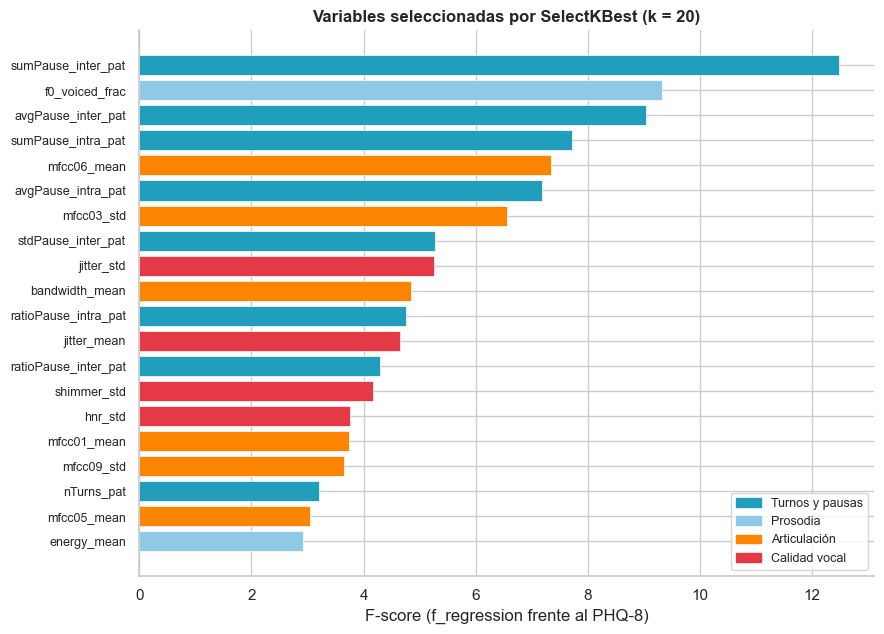

Guardado: output/tabla_seleccion_features.csv


In [8]:
# Figura: F-score de las 20 seleccionadas, coloreado por bloque
sel20 = tab_sel[tab_sel.Sel].sort_values('F')
COLB = {'Turnos y pausas': PALETA4[1], 'Prosodia': PALETA4[0],
        'Articulación': PALETA4[2], 'Calidad vocal': PALETA4[3]}

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(sel20.Variable, sel20.F, color=[COLB[b] for b in sel20.Bloque],
        edgecolor='white', linewidth=0.5)
ax.set_xlabel('F-score (f_regression frente al PHQ-8)')
ax.tick_params(axis='y', labelsize=9)
ax.set_title('Variables seleccionadas por SelectKBest (k = 20)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=v, label=k) for k, v in COLB.items()],
          fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(path_output + '/eda_seleccion_features.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

tab_sel.to_csv(path_output + '/tabla_seleccion_features.csv', index=False)
print('Guardado: output/tabla_seleccion_features.csv')